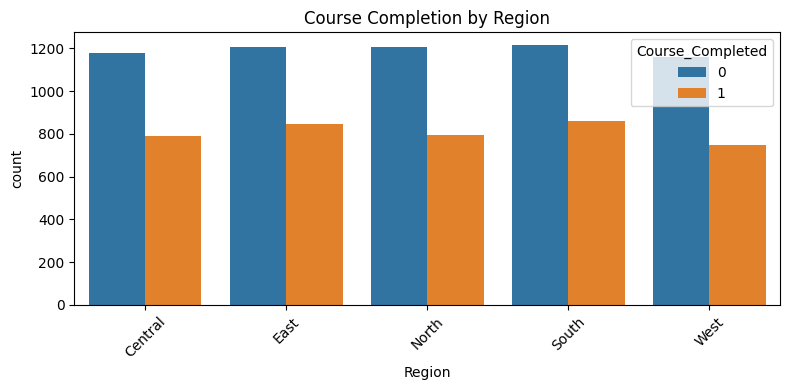

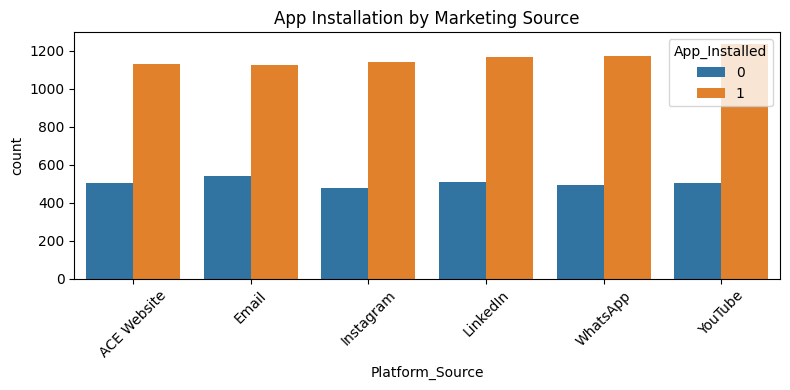

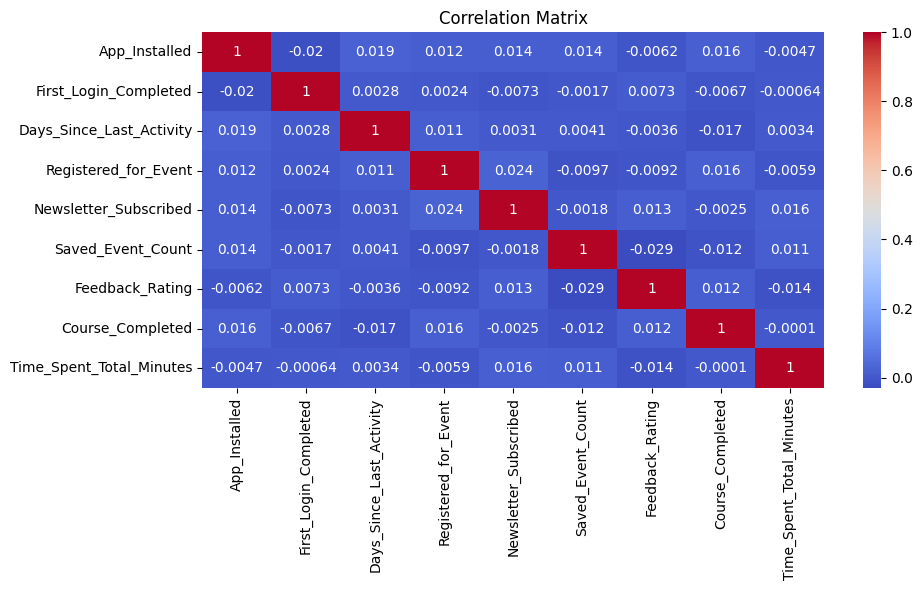

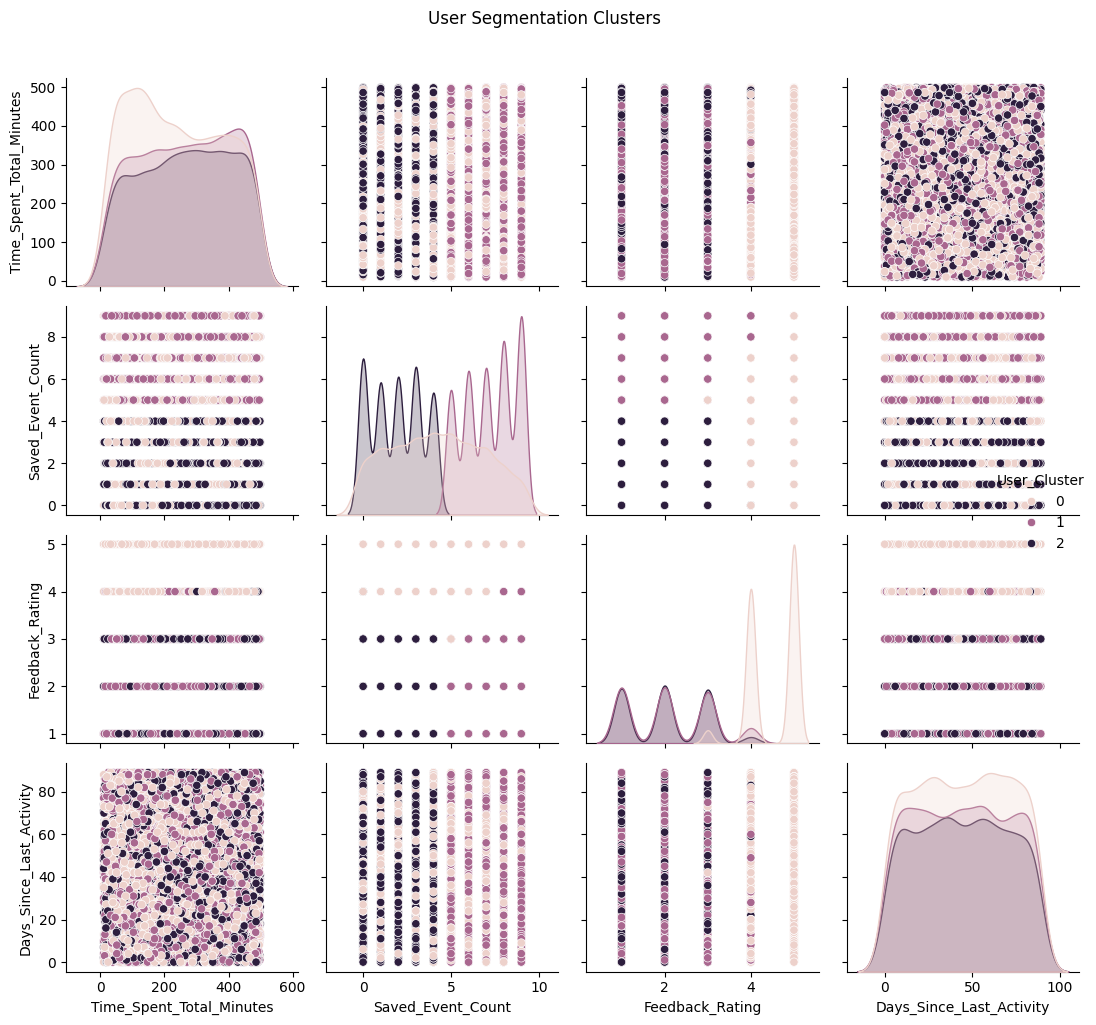

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.76      0.66      1170
           1       0.43      0.25      0.31       830

    accuracy                           0.55      2000
   macro avg       0.51      0.51      0.49      2000
weighted avg       0.52      0.55      0.52      2000



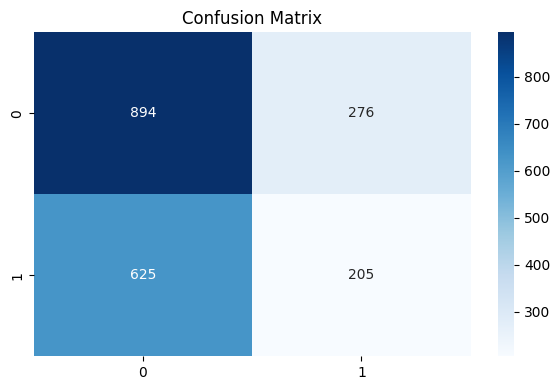

C:\Users\BALAJI\AppData\Local\Temp\ipykernel_5520\3518978331.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  roi = df.groupby("Platform_Source").agg({


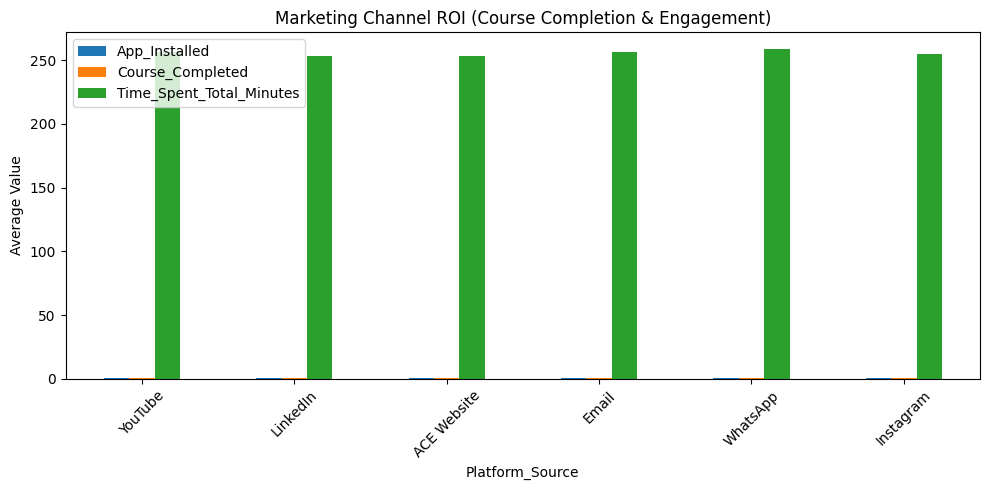

,User_ID,User_Cluster,Course_Completed,Platform_Source
9995,ECL109995,0,0,ACE Website
9996,ECL109996,0,1,WhatsApp
9997,ECL109997,0,0,Email
9998,ECL109998,0,0,Instagram
9999,ECL109999,1,0,YouTube


In [2]:
# ECLEARNIX Analytics Notebook
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Load dataset
df = pd.read_excel("F:\ECL\ECLEARNIX_Hackathon_10K_Dataset (1).xlsx")

# Convert relevant columns to category
categorical_cols = ['User_Type', 'Department', 'Region', 'Platform_Source', 'Event_Type', 'Event_Mode']
for col in categorical_cols:
    df[col] = df[col].astype('category')

# ----- EDA -----
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Region', hue='Course_Completed')
plt.title('Course Completion by Region')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='Platform_Source', hue='App_Installed')
plt.title('App Installation by Marketing Source')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

# ----- Clustering -----
features = ['Time_Spent_Total_Minutes', 'Saved_Event_Count', 'Feedback_Rating', 'Days_Since_Last_Activity']
X_cluster = df[features].fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['User_Cluster'] = kmeans.fit_predict(X_scaled)

sns.pairplot(df, hue='User_Cluster', vars=features)
plt.suptitle("User Segmentation Clusters", y=1.02)
plt.tight_layout()
plt.show()

# ----- Predictive Modeling -----
predict_features = ['App_Installed', 'First_Login_Completed', 'Newsletter_Subscribed', 
                    'Days_Since_Last_Activity', 'Registered_for_Event', 
                    'Saved_Event_Count', 'Feedback_Rating', 'Time_Spent_Total_Minutes']

X = df[predict_features]
y = df['Course_Completed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Classification Report:\n", classification_report(y_test, y_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# ----- Marketing ROI -----
roi = df.groupby("Platform_Source").agg({
    'App_Installed': 'mean',
    'Course_Completed': 'mean',
    'Time_Spent_Total_Minutes': 'mean'
}).sort_values("Course_Completed", ascending=False)

roi.plot(kind='bar', figsize=(10, 5))
plt.title("Marketing Channel ROI (Course Completion & Engagement)")
plt.ylabel("Average Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Final insights
df[['User_ID', 'User_Cluster', 'Course_Completed', 'Platform_Source']].tail()
